In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt


In [2]:
#%pip install pycox torchtuples torch scikit-learn matplotlib pandas numpy

import torch
import torchtuples as tt
from pycox.models import CoxPH
from pycox.evaluation import EvalSurv

In [48]:
#from Preprocessing.PreprocessingBrainCancer import prepare_brain_cancer_data as prepare_data
#from Preprocessing.PreprocessingBreastCancer import prepare_breast_cancer_data as prepare_data
#from Preprocessing.PreprocessingLeukemia import prepare_leukemia_data as prepare_data 
#from Preprocessing.PreprocessingLungCancer import prepare_lung_cancer_data as prepare_data
#from Preprocessing.PreprocessingLymphoma import prepare_lymphoma_data as prepare_data
#from Preprocessing.PreprocessingProstateCancer import prepare_prostate_cancer_data as prepare_data
from Preprocessing.PreprocessingSmallIntestineCancer import prepare_small_intestine_cancer_data as prepare_data

x_train, y_train, val_data, x_test, y_test = prepare_data("C:\\Users\\kubap\\OneDrive\\Pulpit\\magisterka ekperymenty\\Datasets\\_SmallIntestineCancerUsaDataset.csv")

#laptop
# C:\\Users\\kubap\\Desktop\\magisterka ekperymenty\\Datasets\\

#komputer dom
# C:\\Users\\kubap\\OneDrive\\Pulpit\\magisterka ekperymenty\\Datasets\\

Dane wczytane. Rozmiar początkowy: (21347, 24)

Rozmiar X_train: (12615, 67)


In [49]:
all_events = np.concatenate([
    y_train[1],
    val_data[1][1],
    y_test[1]
])

censored_count = (all_events == 0).sum()
dead_count = (all_events == 1).sum()
total_patients = len(all_events)

censored_percent = (censored_count / total_patients) * 100

print(f"liczba pacjentów: {total_patients}")
print(f"liczba pacjentów cenzurowanych event=0: {censored_count} ({censored_percent:.2f}%)")
print(f"liczba pacjentów event=1: {dead_count} ({(100 - censored_percent):.2f}%)")

liczba pacjentów: 21026
liczba pacjentów cenzurowanych event=0: 7844 (37.31%)
liczba pacjentów event=1: 13182 (62.69%)


In [ ]:
# DeepSurv - MLPVanilla z 1 warstwą ukrytą (32 neurony), batch normalization i dropoutem (0.5)

net = tt.practical.MLPVanilla(
    in_features=x_train.shape[1], 
    num_nodes=[32, 32], 
    out_features=1, 
    batch_norm=True, 
    dropout=0.5
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

optimizer = tt.optim.Adam(weight_decay=0.01)

model = CoxPH(net, optimizer, device=device)

model.optimizer.set_lr(0.0001) 


Rozpoczęcie uczenia modelu DeepSurv...
0:	[0s / 0s],		train_loss: 5.0400,	val_loss: 9.8448
1:	[0s / 0s],		train_loss: 4.9843,	val_loss: 8.5765
2:	[0s / 0s],		train_loss: 4.9053,	val_loss: 8.5527
3:	[0s / 1s],		train_loss: 4.8965,	val_loss: 8.3505
4:	[0s / 1s],		train_loss: 4.7877,	val_loss: 7.7119
5:	[0s / 1s],		train_loss: 4.7843,	val_loss: 7.6783
6:	[0s / 1s],		train_loss: 4.7309,	val_loss: 7.6965
7:	[0s / 2s],		train_loss: 4.7423,	val_loss: 7.5107
8:	[0s / 2s],		train_loss: 4.7129,	val_loss: 7.4688
9:	[0s / 2s],		train_loss: 4.6892,	val_loss: 7.4615
10:	[0s / 2s],		train_loss: 4.6602,	val_loss: 7.4318
11:	[0s / 3s],		train_loss: 4.6415,	val_loss: 7.4208
12:	[0s / 3s],		train_loss: 4.7111,	val_loss: 7.3900
13:	[0s / 3s],		train_loss: 4.6118,	val_loss: 7.3721
14:	[0s / 3s],		train_loss: 4.6138,	val_loss: 7.3633
15:	[0s / 4s],		train_loss: 4.6015,	val_loss: 7.3498
16:	[0s / 4s],		train_loss: 4.5835,	val_loss: 7.3396
17:	[0s / 4s],		train_loss: 4.5788,	val_loss: 7.3287
18:	[0s / 4s],		t

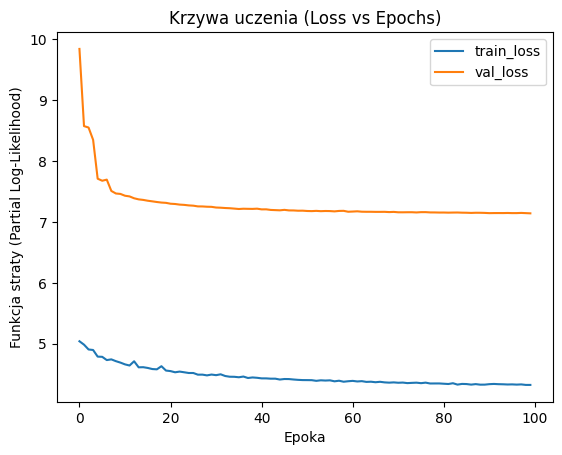

In [54]:
# Uczenie Modelu
batch_size = 256
epochs = 100
callbacks = [tt.callbacks.EarlyStopping(patience=10)]

print("Rozpoczęcie uczenia modelu DeepSurv...")
log = model.fit(x_train, y_train, batch_size, epochs, callbacks, val_data=val_data)

# wykres funkcji straty podczas uczenia
_ = log.plot()
plt.title("Krzywa uczenia (Loss vs Epochs)")
plt.xlabel("Epoka")
plt.ylabel("Funkcja straty (Partial Log-Likelihood)")
plt.show()

In [55]:
# Ewaluacja na zbiorze testowym
_ = model.compute_baseline_hazards()

surv_test = model.predict_surv_df(x_test)

ev = EvalSurv(surv_test, y_test[0], y_test[1], censor_surv='km')

In [56]:
# C-index
c_index = ev.concordance_td()
print(f"Time-Dependent Concordance Index (C-index): {c_index:.4f}")

import scipy.integrate
if not hasattr(scipy.integrate, "simps"):
    scipy.integrate.simps = scipy.integrate.simpson

# Brier Score
time_grid = np.linspace(y_test[0].min(), y_test[0].max(), 100)
brier_score = ev.brier_score(time_grid)
integrated_brier_score = ev.integrated_brier_score(time_grid)
print(f"Integrated Brier Score (IBS): {integrated_brier_score:.4f}")

Time-Dependent Concordance Index (C-index): 0.7746
Integrated Brier Score (IBS): 0.1135


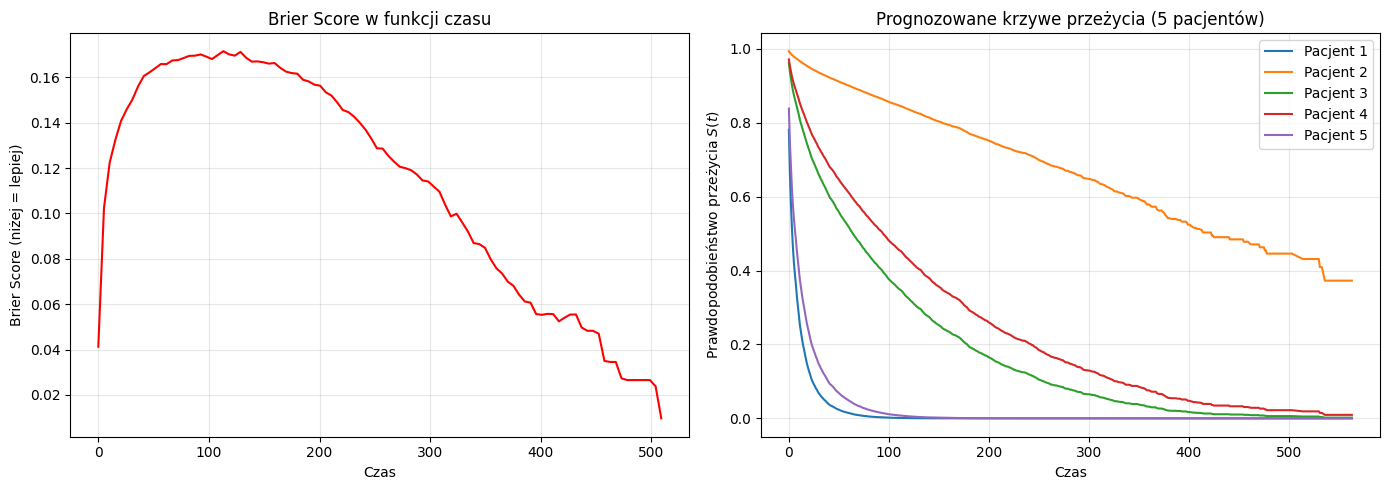

In [57]:
# Wykresy
plt.figure(figsize=(14, 5))

# Brier Score
plt.subplot(1, 2, 1)
plt.plot(time_grid, brier_score, color='red')
plt.title("Brier Score w funkcji czasu")
plt.xlabel("Czas")
plt.ylabel("Brier Score (niżej = lepiej)")
plt.grid(True, alpha=0.3)

# krzywe przeżycia dla pierwszych 5 pacjentów ze zbioru testowego
plt.subplot(1, 2, 2)
for i in range(5):
    plt.plot(surv_test.index, surv_test.iloc[:, i], label=f'Pacjent {i+1}')
plt.title("Prognozowane krzywe przeżycia (5 pacjentów)")
plt.xlabel("Czas")
plt.ylabel("Prawdopodobieństwo przeżycia $S(t)$")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [3]:
import torch

print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No CUDA device available")

2.7.1+cu118
11.8
True
NVIDIA GeForce GTX 1050 Ti


In [1]:
import scipy.integrate
scipy.integrate.simps = getattr(scipy.integrate, 'simpson', scipy.integrate.trapezoid)

import numpy as np
import pandas as pd
import datetime
import os
import matplotlib.pyplot as plt
import torch
import torchtuples as tt

from pycox.evaluation import EvalSurv
from pycox.models import CoxPH

from Preprocessing.PreprocessingBrainCancer import prepare_brain_cancer_data
from Preprocessing.PreprocessingBreastCancer import prepare_breast_cancer_data
from Preprocessing.PreprocessingLeukemia import prepare_leukemia_data
from Preprocessing.PreprocessingLungCancer import prepare_lung_cancer_data
from Preprocessing.PreprocessingLymphoma import prepare_lymphoma_data
from Preprocessing.PreprocessingProstateCancer import prepare_prostate_cancer_data
from Preprocessing.PreprocessingSmallIntestineCancer import prepare_small_intestine_cancer_data

#laptop
#base_path = "C:\\Users\\kubap\\Desktop\\magisterka ekperymenty\\Datasets\\"

#komputer dom
base_path = "C:\\Users\\kubap\\OneDrive\\Pulpit\\magisterka ekperymenty\\Datasets\\"

datasets = {
    "Brain Cancer": (prepare_brain_cancer_data, base_path + "_BrainCancerUsaDataset.csv"),
    "Breast Cancer": (prepare_breast_cancer_data, base_path + "_BreastCancerUsaDataset.csv"),
    "Leukemia": (prepare_leukemia_data, base_path + "_LeukemiaUsaDataset.csv"),
    "Lung Cancer": (prepare_lung_cancer_data, base_path + "_LungCancerUsaDataset.csv"),
    "Lymphoma": (prepare_lymphoma_data, base_path + "_LymphomaUsaDataset.csv"),
    "Prostate Cancer": (prepare_prostate_cancer_data, base_path + "_ProstateCancerUsaDataset.csv"),
    "Small Intestine Cancer": (prepare_small_intestine_cancer_data, base_path + "_SmallIntestineCancerUsaDataset.csv")
}

output_folder = "Wykresy_Eksperymenty_DeepSurv"
os.makedirs(output_folder, exist_ok=True)

def run_single_experiment(x_train, y_train, val_data, x_test, y_test):
    in_features = x_train.shape[1]
    
    net = tt.practical.MLPVanilla(
        in_features=in_features, 
        num_nodes=[32, 32], 
        out_features=1, 
        batch_norm=True, 
        dropout=0.3
    )
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    optimizer = tt.optim.Adam(weight_decay=0.01)
    model = CoxPH(net, optimizer, device=device)
    model.optimizer.set_lr(0.0001)
    
    batch_size = 256
    epochs = 100
    callbacks = [tt.callbacks.EarlyStopping(patience=10)]
    
    log = model.fit(x_train, y_train, batch_size, epochs, callbacks, val_data=val_data, verbose=False)
    
    _ = model.compute_baseline_hazards()
    
    # EWALUACJA
    surv_test = model.predict_surv_df(x_test)
    ev = EvalSurv(surv_test, y_test[0], y_test[1], censor_surv='km')
    c_index = ev.concordance_td()
    
    time_grid = np.linspace(y_test[0].min(), y_test[0].max(), 100)
    ibs = ev.integrated_brier_score(time_grid)
    brier_score_time = ev.brier_score(time_grid)
    
    return c_index, ibs, brier_score_time, log, surv_test, time_grid

# glowna petla i raporty

num_runs = 10
output_filename = "wyniki_eksperymentow_DeepSurv.txt"

print(f"START DEEPSURV. Wyniki -> {output_filename}, Wykresy -> folder '{output_folder}'")

with open(output_filename, "w", encoding="utf-8") as file:
    file.write(f"RAPORT - DEEPSURV\n")
    
    for dataset_name, (prep_func, filepath) in datasets.items():
        print(f"\n[{dataset_name}] Wczytywanie danych")
        file.write(f"\nZBIÓR: {dataset_name}\n")
        
        try:
            x_train, y_train, val_data, x_test, y_test = prep_func(filepath)
        except Exception as e:
            print(f"Błąd podczas wczytywania {dataset_name}: {e}")
            continue

        all_c_indexes, all_ibses = [], []
        all_brier_scores = []
        
        best_c_index = -1
        best_log = None
        best_surv_test = None
        final_time_grid = None

        print(f"Uruchamianie {num_runs} powtórzeń...")
        for i in range(num_runs):
            print(f"   Bieg {i+1}/{num_runs}...", end=" ", flush=True)
            
            c_idx, ibs, brier_st, log, surv_t, t_grid = run_single_experiment(
                x_train, y_train, val_data, x_test, y_test
            )
            
            all_c_indexes.append(c_idx)
            all_ibses.append(ibs)
            all_brier_scores.append(brier_st)
            
            # zapis najlepszego modelu
            if c_idx > best_c_index:
                best_c_index = c_idx
                best_log = log
                best_surv_test = surv_t
                final_time_grid = t_grid
                
            print(f"Gotowe (C-index: {c_idx:.4f})")

        # statystyki
        mean_c = np.mean(all_c_indexes)
        std_c = np.std(all_c_indexes)
        mean_ibs = np.mean(all_ibses)
        std_ibs = np.std(all_ibses)
        
        avg_brier = np.mean(all_brier_scores, axis=0)

        file.write(f"C-index (średnia): {mean_c:.4f} +/- {std_c:.4f}\n")
        file.write(f"IBS (średnia):     {mean_ibs:.4f} +/- {std_ibs:.4f}\n")
        file.write(f"Najlepszy C-index: {best_c_index:.4f}\n\n")

        # wykresy
        print(f"Generowanie i zapisywanie uśrednionych wykresów dla {dataset_name}...")
        prefix = f"{output_folder}/{dataset_name.replace(' ', '_')}"

        # Brier Score w czasie (avg z 10 przebiegów)
        plt.figure(figsize=(8, 5))
        plt.plot(final_time_grid, avg_brier, color='blue', linewidth=2)
        plt.title(f"Średni Brier Score w czasie (Klasyczny) - {dataset_name}")
        plt.xlabel("Czas (Miesiące)")
        plt.ylabel("Brier Score")
        plt.ylim(0, 0.3)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(f"{prefix}_IBS_w_czasie.png", dpi=300)
        plt.close()

        # krzywa uczenia (z najlepszego modelu)
        plt.figure(figsize=(8, 5))
        best_log.plot()
        plt.title(f"Krzywa uczenia (Klasyczny - Najlepszy model) - {dataset_name}")
        plt.xlabel("Epoki")
        plt.ylabel("Loss")
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(f"{prefix}_Krzywa_Uczenia.png", dpi=300)
        plt.close()

        # krzywe przeżycia dla pacjentów testowych (z najlepszego modelu)
        plt.figure(figsize=(8, 5))
        for i in range(min(5, best_surv_test.shape[1])):
            plt.plot(best_surv_test.index, best_surv_test.iloc[:, i], label=f'Pacjent {i+1}')
        plt.title(f"Przeżycie 5 pacjentów (Klasyczny) - {dataset_name}")
        plt.xlabel("Czas (Miesiące)")
        plt.ylabel("Prawdopodobieństwo Przeżycia")
        plt.ylim(0, 1.05)
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.savefig(f"{prefix}_Przezycie_5_Pacjentow.png", dpi=300)
        plt.close()

print("Pełen sukces! Eksperyment zakończony")

START DEEPSURV. Wyniki -> wyniki_eksperymentow_DeepSurv.txt, Wykresy -> folder 'Wykresy_Eksperymenty_DeepSurv'

[Brain Cancer] Wczytywanie danych
Dane wczytane. Rozmiar początkowy: (66994, 19)

Rozmiar X_train: (39431, 201)
Uruchamianie 10 powtórzeń...
   Bieg 1/10... Gotowe (C-index: 0.7928)
   Bieg 2/10... Gotowe (C-index: 0.7933)
   Bieg 3/10... Gotowe (C-index: 0.7925)
   Bieg 4/10... Gotowe (C-index: 0.7932)
   Bieg 5/10... Gotowe (C-index: 0.7926)
   Bieg 6/10... Gotowe (C-index: 0.7938)
   Bieg 7/10... Gotowe (C-index: 0.7926)
   Bieg 8/10... Gotowe (C-index: 0.7928)
   Bieg 9/10... Gotowe (C-index: 0.7937)
   Bieg 10/10... Gotowe (C-index: 0.7923)
Generowanie i zapisywanie uśrednionych wykresów dla Brain Cancer...

[Breast Cancer] Wczytywanie danych
Dane wczytane. Rozmiar początkowy: (744632, 20)

Rozmiar X_train: (444663, 104)
Uruchamianie 10 powtórzeń...
   Bieg 1/10... Gotowe (C-index: 0.7730)
   Bieg 2/10... Gotowe (C-index: 0.7726)
   Bieg 3/10... Gotowe (C-index: 0.7726)


<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>